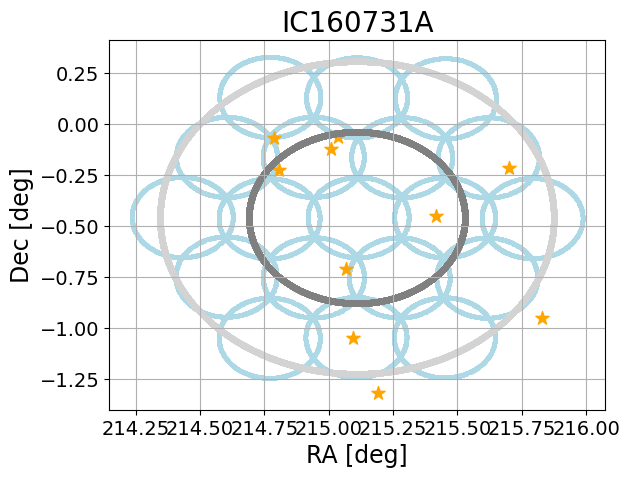

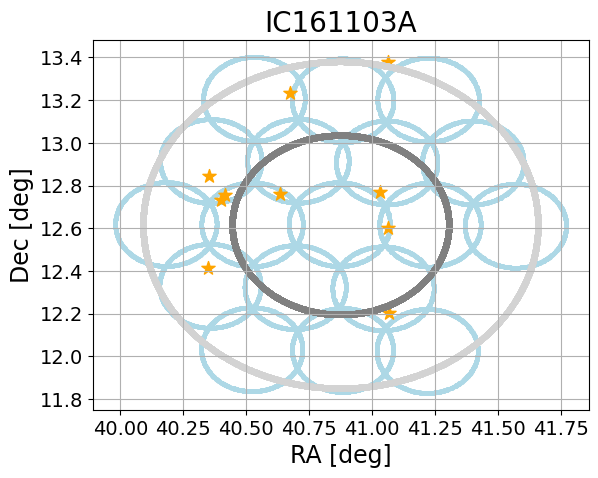

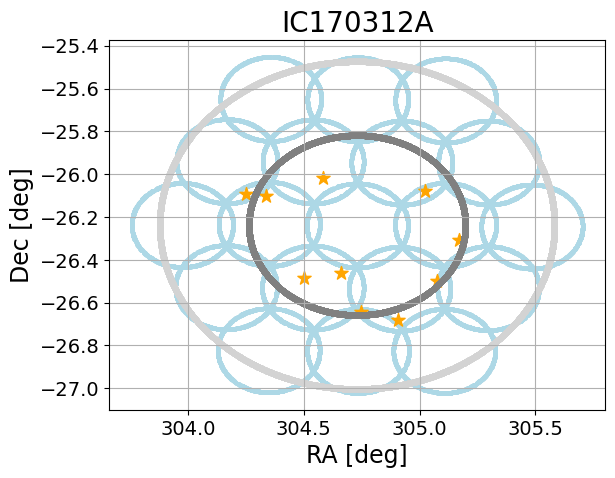

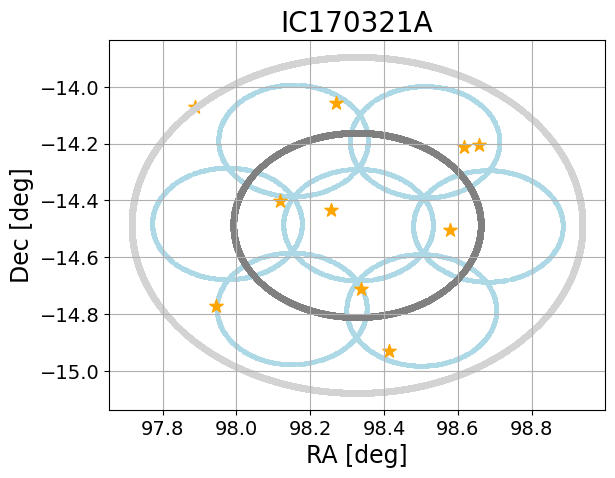

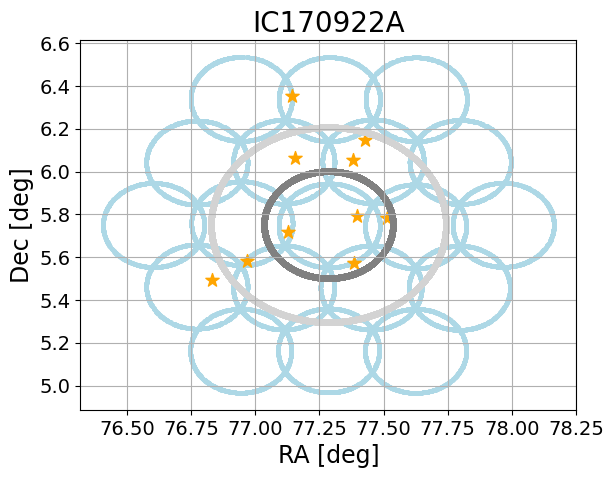

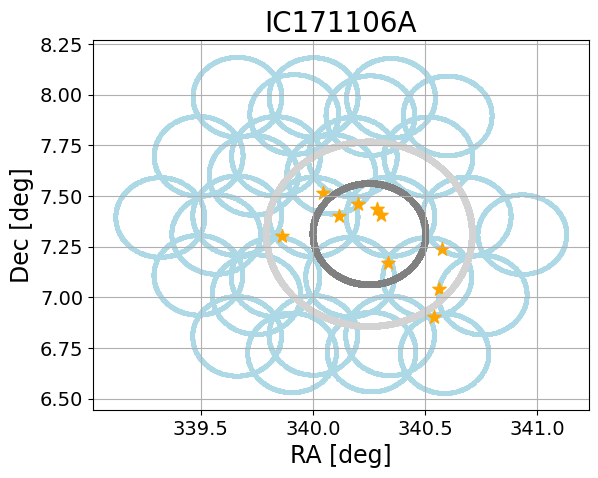

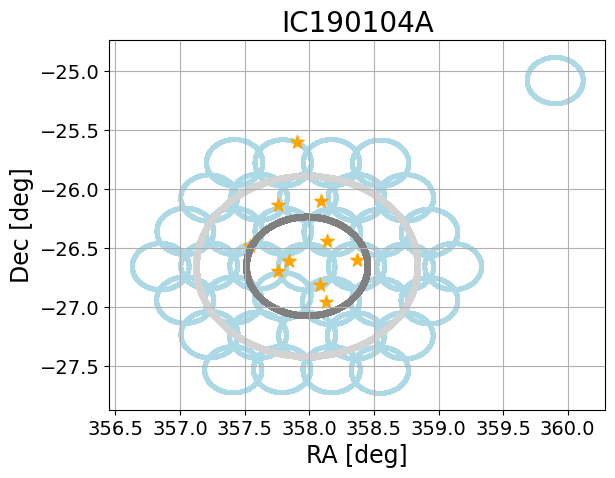

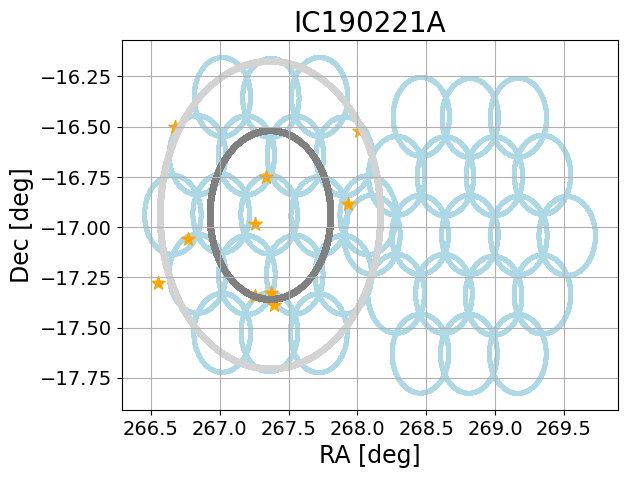

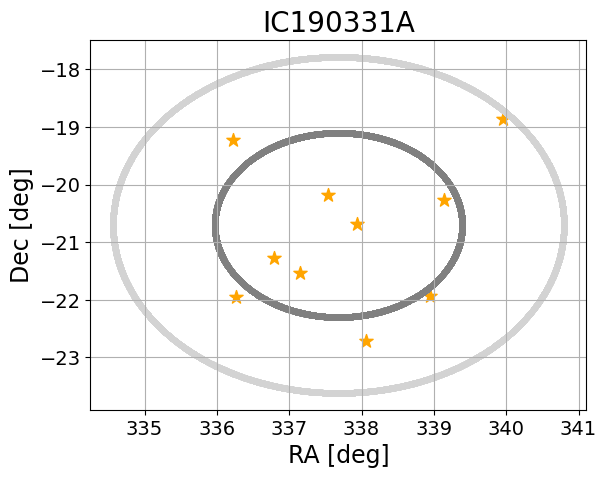

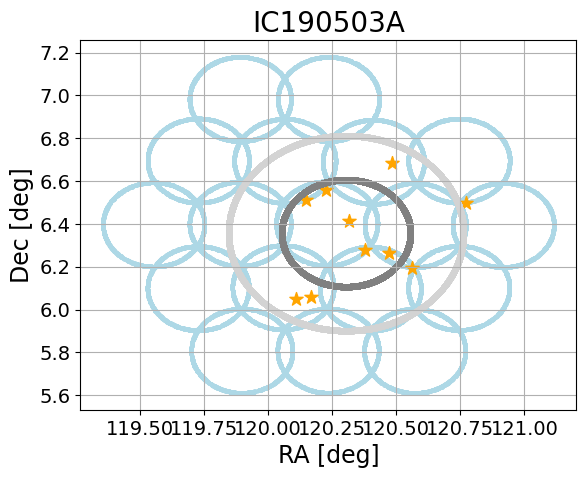

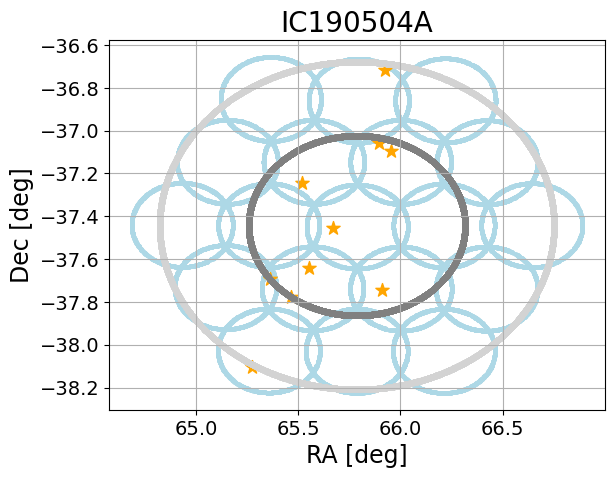

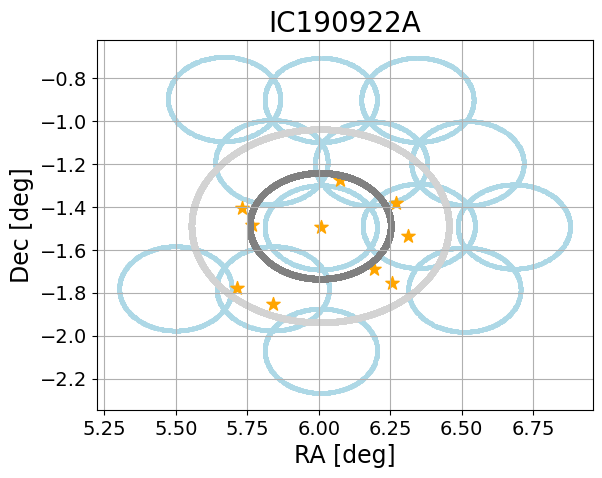

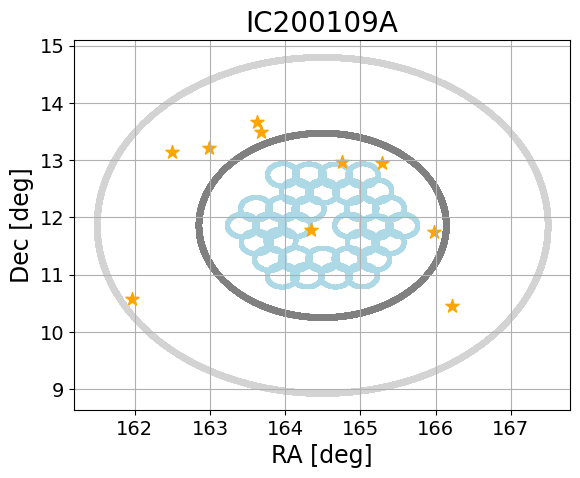

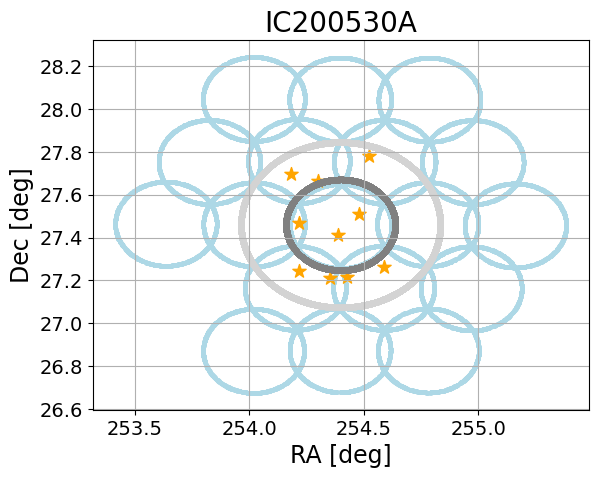

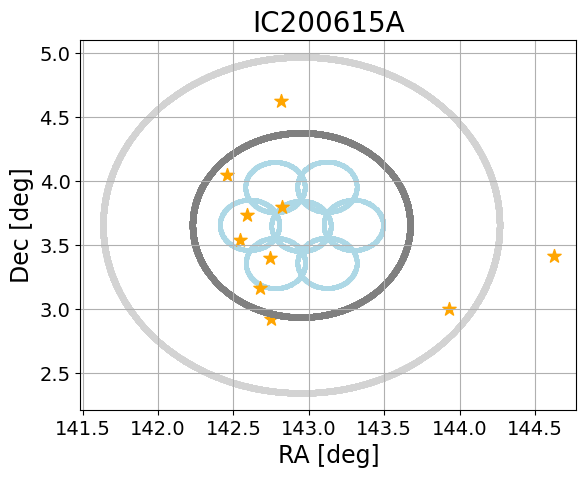

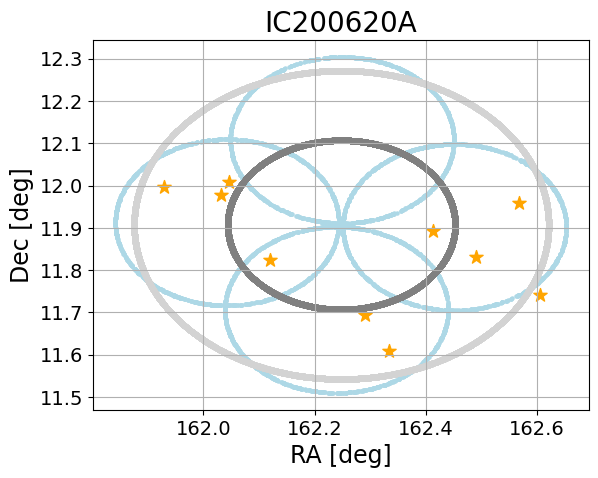

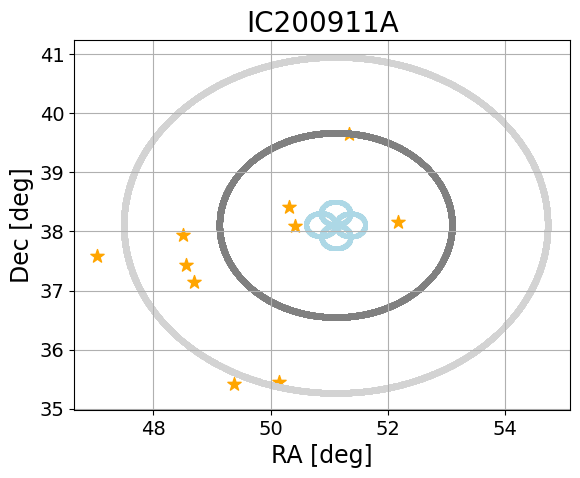

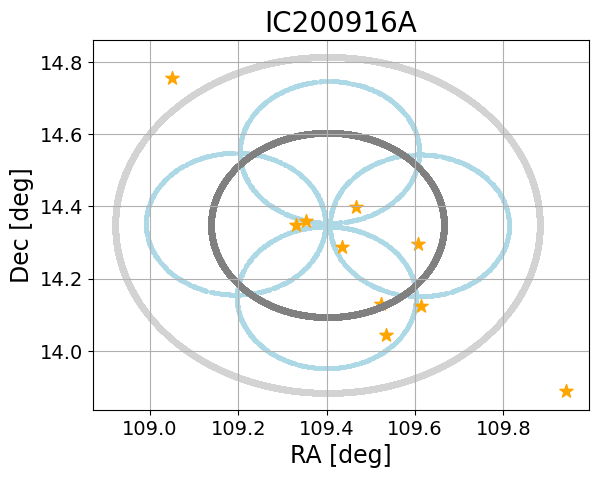

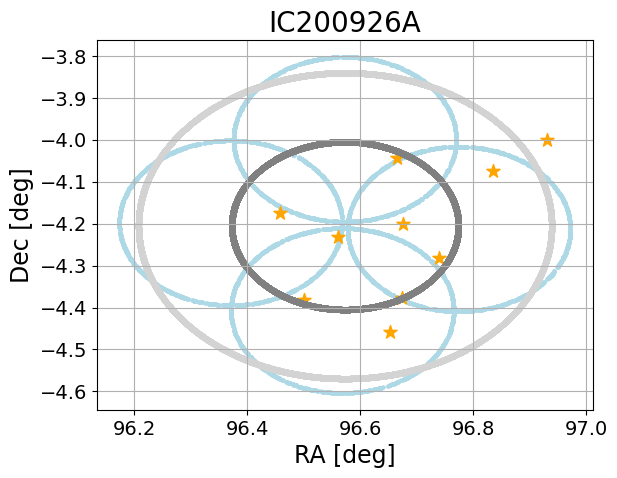

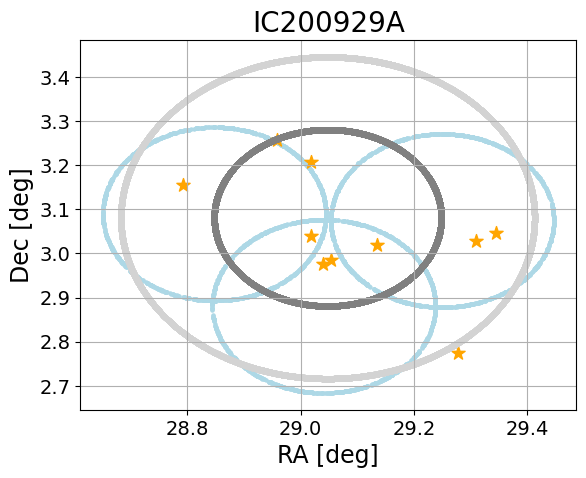

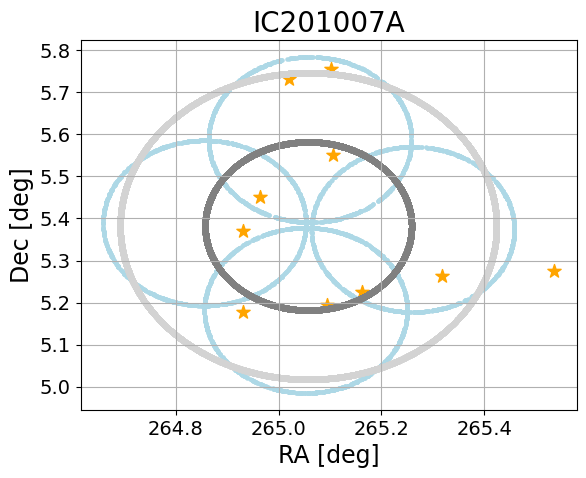

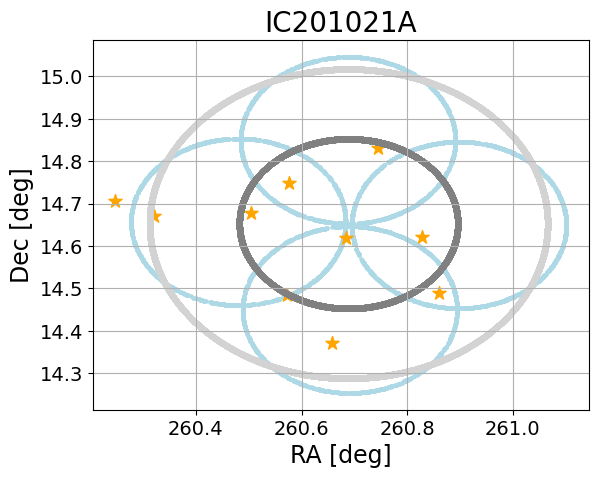

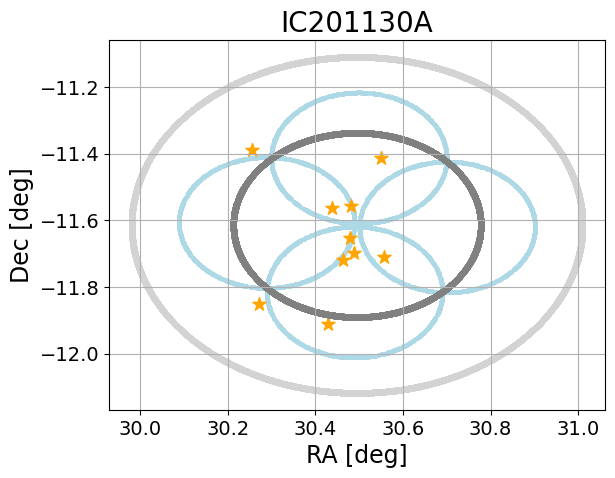

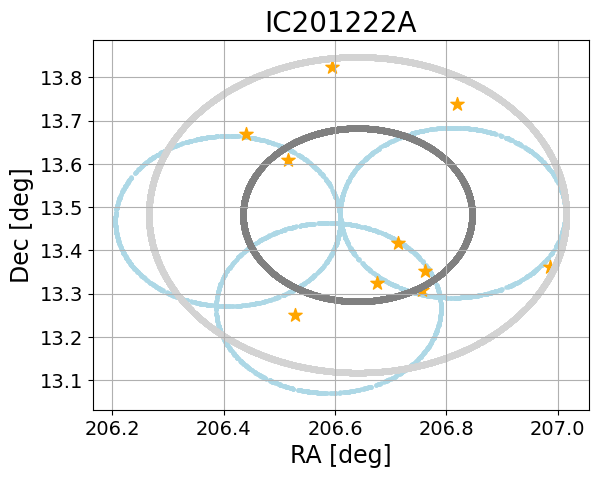

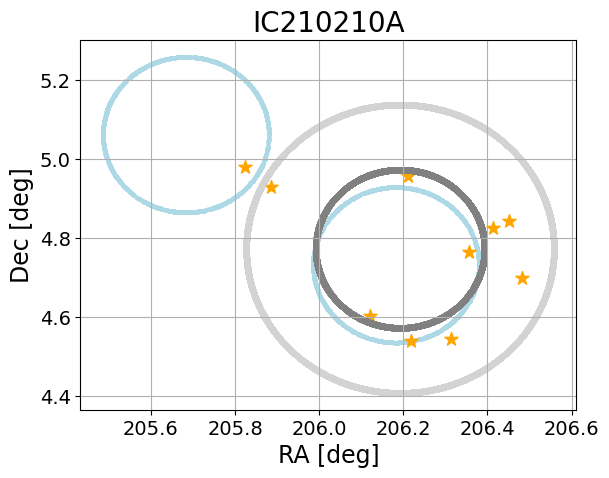

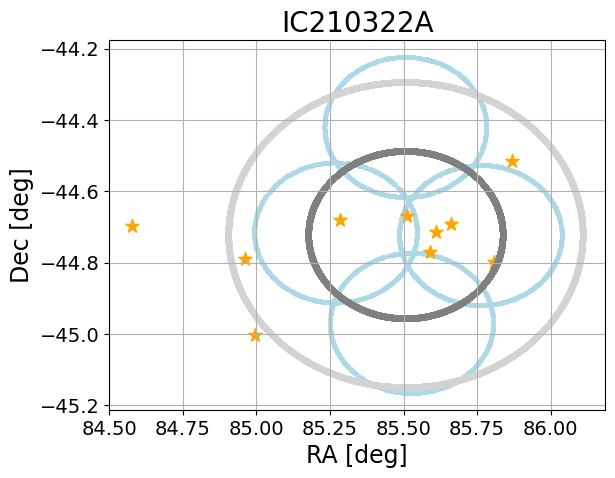

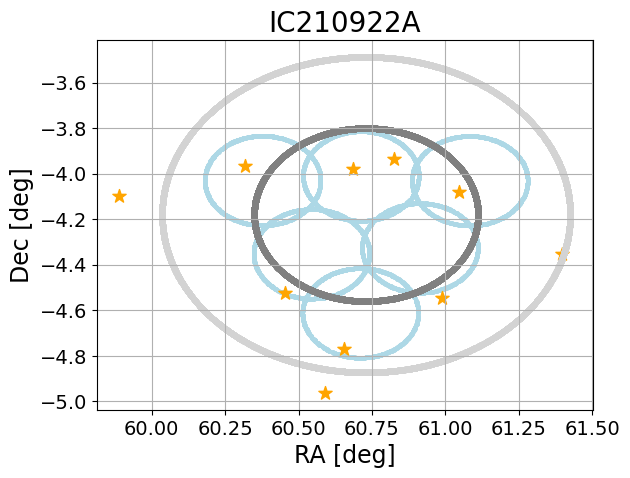

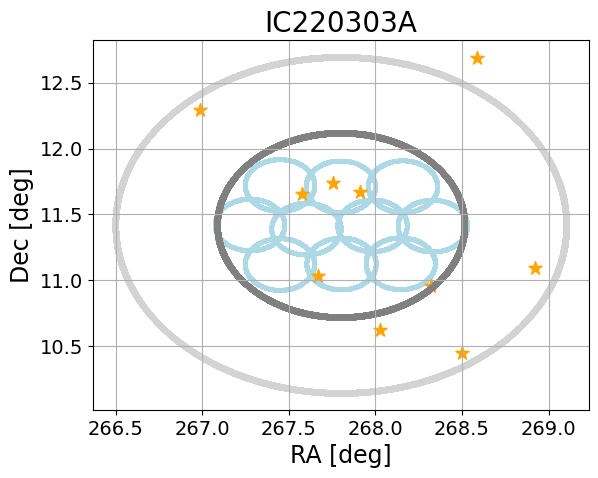

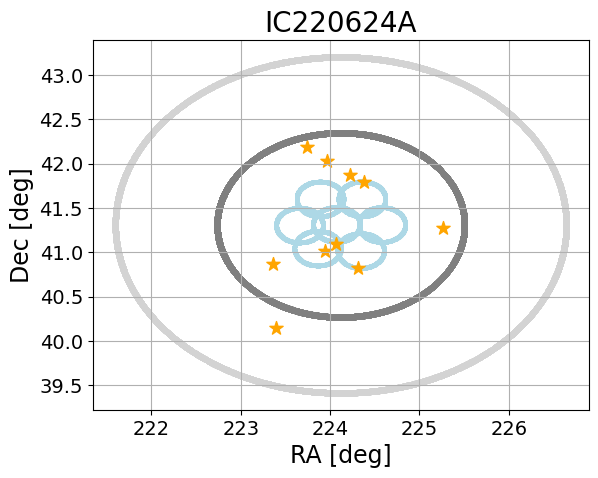

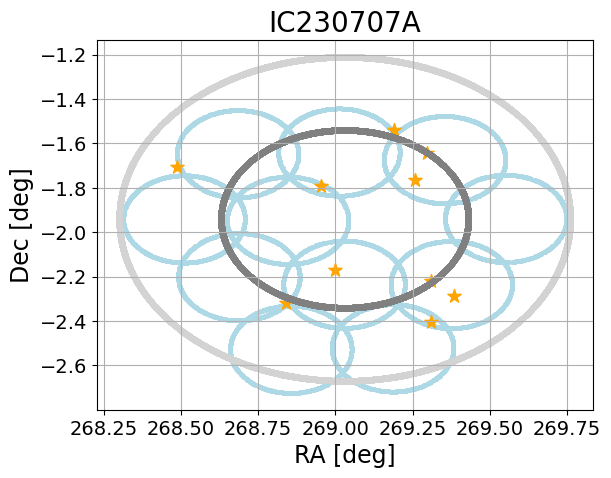

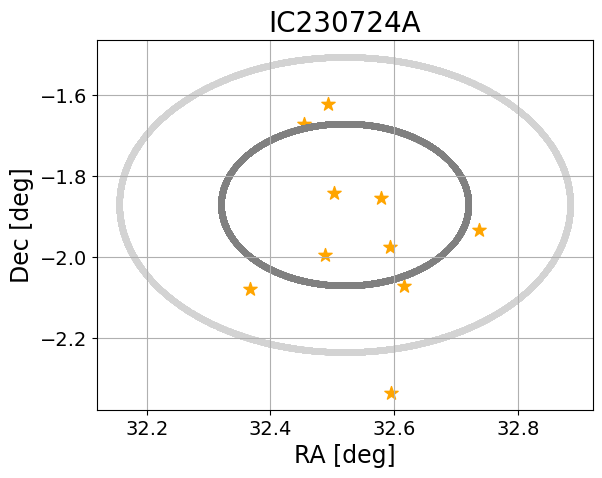

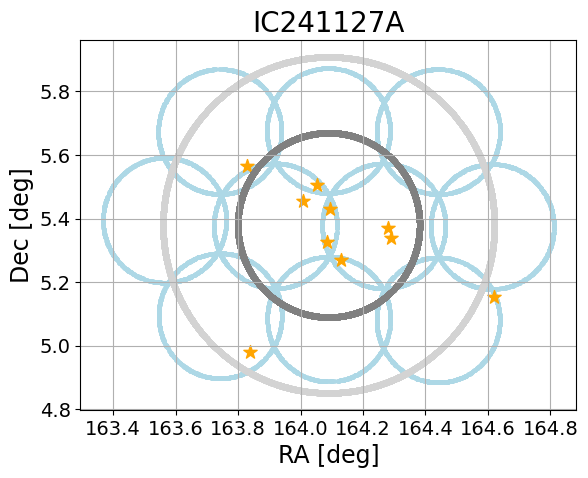

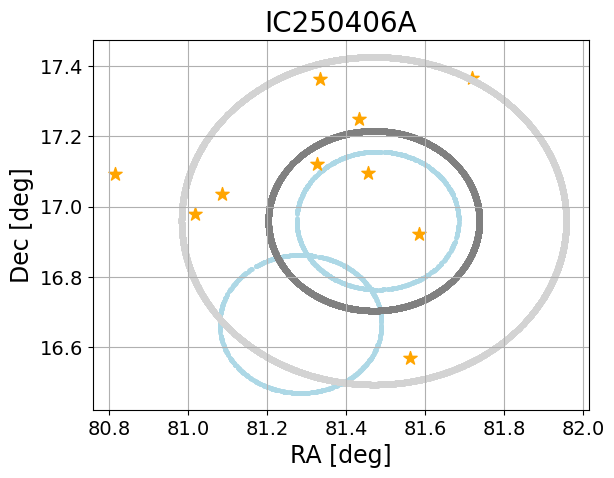

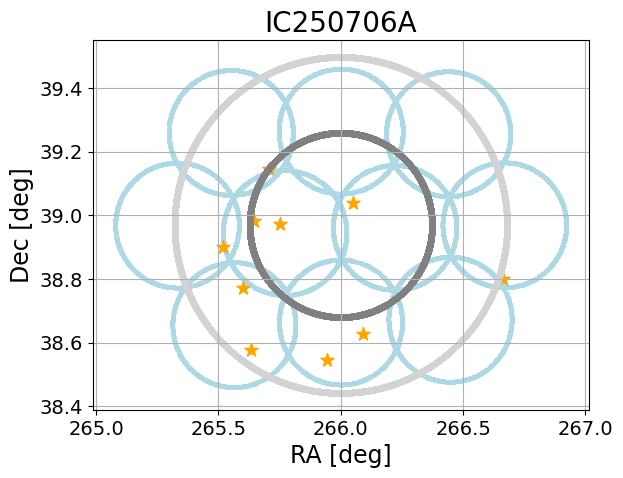

In [4]:
def extract_target_id_from_exist_path(exist_path: str) -> str:
    """
    ユーザーの例に合わせて
    exist ファイル名の [5:10] を target として使う。
    """
    existname = Path(exist_path).name
    return str(existname)[5:10]

def conv_RADEC2local(ra, dec, ra_pnt, dec_pnt, DELX, DELY, RPX, RPY):
    ra_rad = np.radians(ra)
    dec_rad = np.radians(dec)
    ra_pnt_rad = np.radians(ra_pnt)
    dec_pnt_rad = np.radians(dec_pnt)
    ca = np.cos(ra_pnt_rad)
    sa = np.sin(ra_pnt_rad)
    cd = np.cos(dec_pnt_rad)
    sd = np.sin(dec_pnt_rad)
    x = np.cos(dec_rad)*np.cos(ra_rad)
    y = np.cos(dec_rad)*np.sin(ra_rad)
    z = np.sin(dec_rad)
    x_ =    -sa*x +    ca*y
    y_ = -ca*sd*x - sa*sd*y + cd*z
    z_ =  ca*cd*x + sa*cd*y + sd*z
    x = RPX + np.degrees(x_) / DELX
    y = RPY + np.degrees(y_) / DELY
    return x, y

import numpy as np

def e50_to_sigma(E50):
    # 2D円対称ガウスの r50 から sigma へ
    return E50 / np.sqrt(2*np.log(2))

def err90(sigma):
    return sigma*np.sqrt(2*np.log(10))

def circle(ra0_deg, dec0_deg, R, size, seed=None):

    rng = np.random.default_rng(seed)

    # 角度単位は一旦ラジアンで扱う
    ra0 = np.deg2rad(ra0_deg)
    dec0 = np.deg2rad(dec0_deg)


    r = np.deg2rad(R)

    # 方向角は一様
    theta = rng.uniform(0, 2*np.pi, size=size)

    # 接平面でのオフセット
    d_dec = r * np.sin(theta)
    # RA方向は cos(dec) で縮むので補正
    cos_dec0 = np.cos(dec0)
    # 極付近の暴走回避（最低限）
    cos_dec0 = np.clip(cos_dec0, 1e-12, None)
    d_ra = (r * np.cos(theta)) / cos_dec0

    ra = ra0 + d_ra
    dec = dec0 + d_dec

    # RA を 0..2π に折り返し
    ra = (ra + 2*np.pi) % (2*np.pi)

    return np.rad2deg(ra), np.rad2deg(dec)

def sample_neutrino_radec(ra0_deg, dec0_deg, E50_deg, n=10, seed=None):

    rng = np.random.default_rng(seed)

    # 角度単位は一旦ラジアンで扱う
    ra0 = np.deg2rad(ra0_deg)
    dec0 = np.deg2rad(dec0_deg)

    sigma_deg = e50_to_sigma(E50_deg)
    sigma = np.deg2rad(sigma_deg)

    # r は Rayleigh
    r = rng.rayleigh(scale=sigma, size=n)

    # 方向角は一様
    theta = rng.uniform(0, 2*np.pi, size=n)

    # 接平面でのオフセット
    d_dec = r * np.sin(theta)
    # RA方向は cos(dec) で縮むので補正
    cos_dec0 = np.cos(dec0)
    # 極付近の暴走回避（最低限）
    cos_dec0 = np.clip(cos_dec0, 1e-12, None)
    d_ra = (r * np.cos(theta)) / cos_dec0

    ra = ra0 + d_ra
    dec = dec0 + d_dec

    # RA を 0..2π に折り返し
    ra = (ra + 2*np.pi) % (2*np.pi)

    return np.rad2deg(ra), np.rad2deg(dec)


datafile = pd.read_csv('/home/yu/XRT/MultipleTiling/full_with_icname_swifttime_obsstart.csv')
exist_npy_name = 'exist_evt_8.6e+04_200.npy'
base = Path('/home/yu/XRT/MultipleTiling')
ic_dirs = sorted([Path(p).name for p in base.glob('IC*') if p.is_dir()])
for IC in ic_dirs:
# IC='IC160731A'

    icname = datafile['ICname']
    RA_0 = datafile['RA'][icname == IC].item()
    DEC_0 = datafile['Dec'][icname == IC].item()
    E50_deg = datafile['Error50'][icname == IC].item()/60
    E90_deg = err90(e50_to_sigma(E50_deg)) 
    exist_path = Path(f"{base}/{IC}/{exist_npy_name}")
    existlist = np.load(exist_path, allow_pickle=True)
    targets = sorted({extract_target_id_from_exist_path(e) for e in existlist})
    ra_inj, dec_inj = sample_neutrino_radec(RA_0, DEC_0, E50_deg)
    # print(RA_inj, DEC_inj)
    err50_ra, err50_dec = circle(RA_0, DEC_0, E50_deg, 10000, seed=None)
    err90_ra, err90_dec = circle(RA_0, DEC_0, E90_deg, 10000, seed=None)
    plt.figure()
    plt.title(f'{IC}', fontsize=20)
    for target in targets:
        hdul = fits.open(f'{base}/{IC}/{target}/sw000{target}001xpcw3po_cl.evt')
        RA_PNT = hdul['EVENTS'].header["RA_PNT"]
        DEC_PNT = hdul['EVENTS'].header["DEC_PNT"]
        TCRPX2 = hdul['EVENTS'].header["TCRPX2"]  
        TCDLT2 = hdul['EVENTS'].header["TCDLT2"]    
        TCRPX3 = hdul['EVENTS'].header["TCRPX3"]    
        TCDLT3 = hdul['EVENTS'].header["TCDLT3"]
        R=TCDLT2*300
        ra_swi, dec_swi = circle(RA_PNT, DEC_PNT, R, 1000, seed=None)
        ra_swi = np.where(ra_swi<5, ra_swi+360, ra_swi)
        plt.scatter(ra_swi, dec_swi, color='lightblue', s=5)

    plt.scatter(ra_inj, dec_inj, marker='*', color='orange', s=100, label='pseudo source dist')
    plt.scatter(err50_ra, err50_dec, color='gray', s=10, label='Err50')
    plt.scatter(err90_ra, err90_dec, color='lightgray', s=10, label='Err90')
    plt.xlabel("RA [deg]", fontsize=17)
    plt.ylabel("Dec [deg]", fontsize=17)
    plt.tick_params(labelsize=14)
    # plt.legend(fontsize=14)
    plt.grid(True)
    plt.show()
    # plt.savefig(f'{base}/{Path(IC)}/ErrandSources.png')

NameError: name 'err50_ra' is not defined

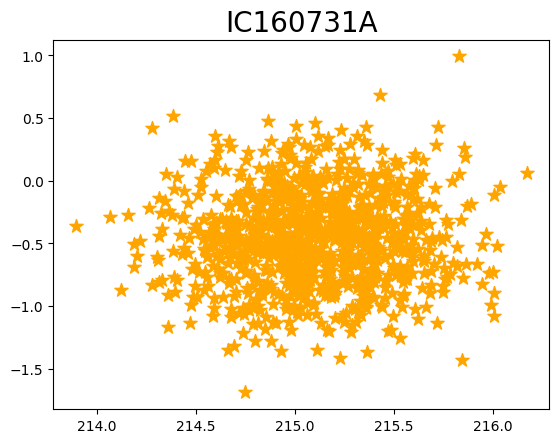

In [4]:
def extract_target_id_from_exist_path(exist_path: str) -> str:
    """
    ユーザーの例に合わせて
    exist ファイル名の [5:10] を target として使う。
    """
    existname = Path(exist_path).name
    return str(existname)[5:10]

def conv_RADEC2local(ra, dec, ra_pnt, dec_pnt, DELX, DELY, RPX, RPY):
    ra_rad = np.radians(ra)
    dec_rad = np.radians(dec)
    ra_pnt_rad = np.radians(ra_pnt)
    dec_pnt_rad = np.radians(dec_pnt)
    ca = np.cos(ra_pnt_rad)
    sa = np.sin(ra_pnt_rad)
    cd = np.cos(dec_pnt_rad)
    sd = np.sin(dec_pnt_rad)
    x = np.cos(dec_rad)*np.cos(ra_rad)
    y = np.cos(dec_rad)*np.sin(ra_rad)
    z = np.sin(dec_rad)
    x_ =    -sa*x +    ca*y
    y_ = -ca*sd*x - sa*sd*y + cd*z
    z_ =  ca*cd*x + sa*cd*y + sd*z
    x = RPX + np.degrees(x_) / DELX
    y = RPY + np.degrees(y_) / DELY
    return x, y

import numpy as np

def e50_to_sigma(E50):
    # 2D円対称ガウスの r50 から sigma へ
    return E50 / np.sqrt(2*np.log(2))



def sample_neutrino_radec(ra0_deg, dec0_deg, E50_deg, n=1000, seed=None):

    rng = np.random.default_rng(seed)

    # 角度単位は一旦ラジアンで扱う
    ra0 = np.deg2rad(ra0_deg)
    dec0 = np.deg2rad(dec0_deg)

    sigma_deg = e50_to_sigma(E50_deg)
    sigma = np.deg2rad(sigma_deg)

    # r は Rayleigh
    r = rng.rayleigh(scale=sigma, size=n)

    # 方向角は一様
    theta = rng.uniform(0, 2*np.pi, size=n)

    # 接平面でのオフセット
    d_dec = r * np.sin(theta)
    # RA方向は cos(dec) で縮むので補正
    cos_dec0 = np.cos(dec0)
    # 極付近の暴走回避（最低限）
    cos_dec0 = np.clip(cos_dec0, 1e-12, None)
    d_ra = (r * np.cos(theta)) / cos_dec0

    ra = ra0 + d_ra
    dec = dec0 + d_dec

    # RA を 0..2π に折り返し
    ra = (ra + 2*np.pi) % (2*np.pi)

    return np.rad2deg(ra), np.rad2deg(dec)


datafile = pd.read_csv('/home/yu/XRT/MultipleTiling/full_with_icname_swifttime_obsstart.csv')
exist_npy_name = 'exist_evt_8.6e+04_200.npy'
base = Path('/home/yu/XRT/MultipleTiling')
ic_dirs = sorted([Path(p).name for p in base.glob('IC*') if p.is_dir()])
# IC='IC160731A'

for IC in ic_dirs:
    icname = datafile['ICname']
    RA_0 = datafile['RA'][icname == IC].item()
    DEC_0 = datafile['Dec'][icname == IC].item()
    E50_deg = datafile['Error50'][icname == IC].item()/60

    exist_path = Path(f"{base}/{IC}/{exist_npy_name}")
    existlist = np.load(exist_path, allow_pickle=True)
    targets = sorted({extract_target_id_from_exist_path(e) for e in existlist})
    ra_inj, dec_inj = sample_neutrino_radec(RA_0, DEC_0, E50_deg)
    # print(RA_inj, DEC_inj)

    plt.figure()
    plt.title(f'{IC}', fontsize=20)
    for target in targets:
        hdul = fits.open(f'{base}/{IC}/{target}/sw000{target}001xpcw3po_cl.evt')
        RA_PNT = hdul['EVENTS'].header["RA_PNT"]
        DEC_PNT = hdul['EVENTS'].header["DEC_PNT"]
        TCRPX2 = hdul['EVENTS'].header["TCRPX2"]  
        TCDLT2 = hdul['EVENTS'].header["TCDLT2"]    
        TCRPX3 = hdul['EVENTS'].header["TCRPX3"]    
        TCDLT3 = hdul['EVENTS'].header["TCDLT3"]
        
        pixels = conv_RADEC2local(ra_inj, dec_inj, RA_PNT, DEC_PNT, TCDLT2, TCDLT3, TCRPX2, TCRPX3)

    plt.scatter(ra_inj, dec_inj, marker='*', color='orange', s=100, label='pseudo source dist')
    plt.scatter(err50_ra, err50_dec, color='gray', s=10, label='Err50')
    plt.scatter(err90_ra, err90_dec, color='lightgray', s=10, label='Err90')
    plt.xlabel("RA [deg]", fontsize=17)
    plt.ylabel("Dec [deg]", fontsize=17)
    plt.tick_params(labelsize=14)
    # plt.legend(fontsize=14)
    plt.grid(True)
    plt.show()
    # plt.savefig(f'{base}/{Path(IC)}/ErrandSources.png')